In [3]:
!pip install nltk pandas numpy scikit-learn matplotlib seaborn joblib --quiet


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import re
import nltk
import joblib

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\shaan\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\shaan\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shaan\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\shaan\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\shaan\AppData\Roaming\nltk_data...


True

In [6]:
data = {
    "review": [
        "The movie was absolutely amazing and entertaining.",
        "I loved this movie because the story was fascinating.",
        "The actors performed brilliantly in this wonderful film.",
        "This was a fantastic movie with excellent acting.",
        "The film was enjoyable and the story was beautiful.",
        "I really liked the movie and would watch it again.",
        "The movie was excellent and very inspiring.",
        "Amazing performances made this movie unforgettable.",
        "The story was engaging and the characters were great.",
        "This is one of the best movies I have ever watched.",
        "The movie was boring and disappointing.",
        "I hated this movie because the story was terrible.",
        "The acting was poor and the movie was extremely boring.",
        "This film was a complete waste of time.",
        "The story was confusing and the characters were annoying.",
        "I did not enjoy the movie at all.",
        "The movie was terrible and predictable.",
        "The film was disappointing and poorly made.",
        "The acting was bad and the story was boring.",
        "I regret watching this horrible movie."
    ],

    "sentiment": [
        "Positive",
        "Positive",
        "Positive",
        "Positive",
        "Positive",
        "Positive",
        "Positive",
        "Positive",
        "Positive",
        "Positive",
        "Negative",
        "Negative",
        "Negative",
        "Negative",
        "Negative",
        "Negative",
        "Negative",
        "Negative",
        "Negative",
        "Negative"
    ]
}

df = pd.DataFrame(data)

df

,review,sentiment
0,The movie was absolutely amazing and entertain...,Positive
1,I loved this movie because the story was fasci...,Positive
2,The actors performed brilliantly in this wonde...,Positive
3,This was a fantastic movie with excellent acting.,Positive
4,The film was enjoyable and the story was beaut...,Positive
5,I really liked the movie and would watch it ag...,Positive
6,The movie was excellent and very inspiring.,Positive
7,Amazing performances made this movie unforgett...,Positive
8,The story was engaging and the characters were...,Positive
9,This is one of the best movies I have ever wat...,Positive


In [7]:
df.to_csv(
    "movie_reviews.csv",
    index=False
)

print("movie_reviews.csv created successfully.")

movie_reviews.csv created successfully.


In [8]:
df = pd.read_csv(
    "movie_reviews.csv"
)

df.head()

,review,sentiment
0,The movie was absolutely amazing and entertain...,Positive
1,I loved this movie because the story was fasci...,Positive
2,The actors performed brilliantly in this wonde...,Positive
3,This was a fantastic movie with excellent acting.,Positive
4,The film was enjoyable and the story was beaut...,Positive


In [9]:
display(df)

,review,sentiment
0,The movie was absolutely amazing and entertain...,Positive
1,I loved this movie because the story was fasci...,Positive
2,The actors performed brilliantly in this wonde...,Positive
3,This was a fantastic movie with excellent acting.,Positive
4,The film was enjoyable and the story was beaut...,Positive
5,I really liked the movie and would watch it ag...,Positive
6,The movie was excellent and very inspiring.,Positive
7,Amazing performances made this movie unforgett...,Positive
8,The story was engaging and the characters were...,Positive
9,This is one of the best movies I have ever wat...,Positive


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     20 non-null     object
 1   sentiment  20 non-null     object
dtypes: object(2)
memory usage: 452.0+ bytes


In [11]:
df.describe(include='all')

,review,sentiment
count,20,20
unique,20,2
top,The movie was absolutely amazing and entertain...,Positive
freq,1,10


In [12]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [13]:
df['sentiment'].value_counts()

sentiment
Positive    10
Negative    10
Name: count, dtype: int64

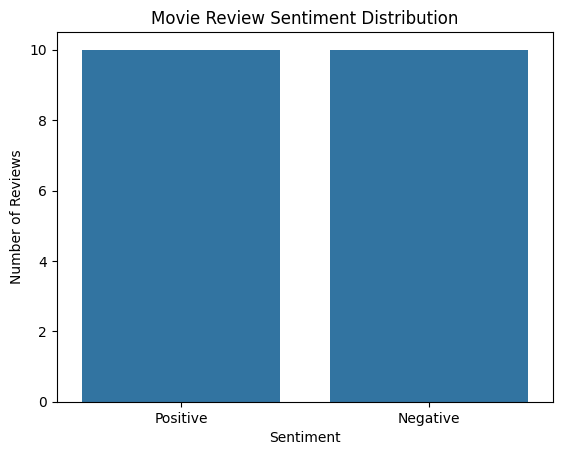

In [14]:
sns.countplot(
    data=df,
    x='sentiment'
)

plt.title(
    "Movie Review Sentiment Distribution"
)

plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

Tokenization

In [15]:
def tokenize_text(text):
    
    text = text.lower()
    
    text = re.sub(
        r'[^a-zA-Z\s]',
        '',
        text
    )
    
    tokens = word_tokenize(
        text
    )
    
    return tokens

In [16]:
sentence = "The movie was absolutely amazing!"

tokens = tokenize_text(
    sentence
)

print("Original Sentence:")
print(sentence)

print("\nTokens:")
print(tokens)

Original Sentence:
The movie was absolutely amazing!

Tokens:
['the', 'movie', 'was', 'absolutely', 'amazing']


In [17]:
stop_words = set(
    stopwords.words('english')
)

print(
    "Number of Stopwords:",
    len(stop_words)
)

print(
    list(stop_words)[:20]
)

Number of Stopwords: 198
['am', 'he', 'll', "weren't", 'can', 'hadn', 'm', "we'll", 'before', "it's", "we've", "mustn't", 'few', 'after', 'this', "needn't", "he's", 'down', 'shan', 'y']


In [18]:
def remove_stopwords(tokens):
    
    return [
        word
        for word in tokens
        if word not in stop_words
    ]

In [19]:

tokens = tokenize_text(
    sentence
)

filtered_tokens = remove_stopwords(
    tokens
)

print("Original Tokens:")
print(tokens)

print("\nAfter Stopword Removal:")
print(filtered_tokens)

Original Tokens:
['the', 'movie', 'was', 'absolutely', 'amazing']

After Stopword Removal:
['movie', 'absolutely', 'amazing']


In [20]:
stemmer = PorterStemmer()

In [21]:
def stem_words(tokens):
    
    return [
        stemmer.stem(word)
        for word in tokens
    ]

In [22]:
words = [
    "playing",
    "played",
    "plays",
    "studies",
    "studying",
    "amazing",
    "entertaining"
]

stemmed_words = stem_words(
    words
)

for original, stemmed in zip(
    words,
    stemmed_words
):
    
    print(
        original,
        "->",
        stemmed
    )

playing -> play
played -> play
plays -> play
studies -> studi
studying -> studi
amazing -> amaz
entertaining -> entertain


In [23]:
lemmatizer = WordNetLemmatizer()

In [24]:
def lemmatize_words(tokens):
    
    return [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

In [25]:
def lemmatize_words(tokens):
    
    return [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

In [26]:
words = [
    "cars",
    "children",
    "mice",
    "studies",
    "movies",
    "actors"
]

lemmatized_words = lemmatize_words(
    words
)

for original, lemma in zip(
    words,
    lemmatized_words
):
    
    print(
        original,
        "->",
        lemma
    )

cars -> car
children -> child
mice -> mouse
studies -> study
movies -> movie
actors -> actor


In [27]:
sentences = [
    "The movie was absolutely amazing and entertaining.",
    "The actors performed brilliantly in this wonderful film.",
    "I loved watching this movie because the story was fascinating.",
    "The plot was confusing, but the ending was surprisingly good.",
    "I did not enjoy the movie because it was boring and predictable."
]

sentences

['The movie was absolutely amazing and entertaining.',
 'The actors performed brilliantly in this wonderful film.',
 'I loved watching this movie because the story was fascinating.',
 'The plot was confusing, but the ending was surprisingly good.',
 'I did not enjoy the movie because it was boring and predictable.']

In [28]:
sentences = [
    "The movie was absolutely amazing and entertaining.",
    "The actors performed brilliantly in this wonderful film.",
    "I loved watching this movie because the story was fascinating.",
    "The plot was confusing, but the ending was surprisingly good.",
    "I did not enjoy the movie because it was boring and predictable."
]

sentences

['The movie was absolutely amazing and entertaining.',
 'The actors performed brilliantly in this wonderful film.',
 'I loved watching this movie because the story was fascinating.',
 'The plot was confusing, but the ending was surprisingly good.',
 'I did not enjoy the movie because it was boring and predictable.']

In [29]:
for i, sentence in enumerate(
    sentences,
    start=1
):

    cleaned = sentence.lower()

    cleaned = re.sub(
        r'[^a-zA-Z\s]',
        '',
        cleaned
    )

    tokens = word_tokenize(
        cleaned
    )

    no_stopwords = remove_stopwords(
        tokens
    )

    stemmed = stem_words(
        no_stopwords
    )

    lemmatized = lemmatize_words(
        no_stopwords
    )

    print("=" * 80)
    print(f"Sentence {i}")
    print("=" * 80)

    print("\nOriginal:")
    print(sentence)

    print("\nTokenization:")
    print(tokens)

    print("\nStopword Removal:")
    print(no_stopwords)

    print("\nStemming:")
    print(stemmed)

    print("\nLemmatization:")
    print(lemmatized)

Sentence 1

Original:
The movie was absolutely amazing and entertaining.

Tokenization:
['the', 'movie', 'was', 'absolutely', 'amazing', 'and', 'entertaining']

Stopword Removal:
['movie', 'absolutely', 'amazing', 'entertaining']

Stemming:
['movi', 'absolut', 'amaz', 'entertain']

Lemmatization:
['movie', 'absolutely', 'amazing', 'entertaining']
Sentence 2

Original:
The actors performed brilliantly in this wonderful film.

Tokenization:
['the', 'actors', 'performed', 'brilliantly', 'in', 'this', 'wonderful', 'film']

Stopword Removal:
['actors', 'performed', 'brilliantly', 'wonderful', 'film']

Stemming:
['actor', 'perform', 'brilliantli', 'wonder', 'film']

Lemmatization:
['actor', 'performed', 'brilliantly', 'wonderful', 'film']
Sentence 3

Original:
I loved watching this movie because the story was fascinating.

Tokenization:
['i', 'loved', 'watching', 'this', 'movie', 'because', 'the', 'story', 'was', 'fascinating']

Stopword Removal:
['loved', 'watching', 'movie', 'story', 'fasc

In [31]:
comparison = []

for sentence in sentences:

    cleaned = sentence.lower()

    cleaned = re.sub(
        r'[^a-zA-Z\s]',
        '',
        cleaned
    )

    tokens = word_tokenize(
        cleaned
    )

    no_stopwords = remove_stopwords(
        tokens
    )

    stemmed = stem_words(
        no_stopwords
    )

    lemmatized = lemmatize_words(
        no_stopwords
    )

    comparison.append({
        "Original": sentence,
        "Tokenized": " ".join(tokens),
        "Stopword Removed": " ".join(no_stopwords),
        "Stemmed": " ".join(stemmed),
        "Lemmatized": " ".join(lemmatized)
    })

comparison_df = pd.DataFrame(
    comparison
)

display(comparison_df)

,Original,Tokenized,Stopword Removed,Stemmed,Lemmatized
0,The movie was absolutely amazing and entertain...,the movie was absolutely amazing and entertaining,movie absolutely amazing entertaining,movi absolut amaz entertain,movie absolutely amazing entertaining
1,The actors performed brilliantly in this wonde...,the actors performed brilliantly in this wonde...,actors performed brilliantly wonderful film,actor perform brilliantli wonder film,actor performed brilliantly wonderful film
2,I loved watching this movie because the story ...,i loved watching this movie because the story ...,loved watching movie story fascinating,love watch movi stori fascin,loved watching movie story fascinating
3,"The plot was confusing, but the ending was sur...",the plot was confusing but the ending was surp...,plot confusing ending surprisingly good,plot confus end surprisingli good,plot confusing ending surprisingly good
4,I did not enjoy the movie because it was borin...,i did not enjoy the movie because it was borin...,enjoy movie boring predictable,enjoy movi bore predict,enjoy movie boring predictable


TF-IDF

In [32]:
def clean_text(text):

    text = text.lower()

    text = re.sub(
        r'[^a-zA-Z\s]',
        '',
        text
    )

    text = re.sub(
        r'\s+',
        ' ',
        text
    ).strip()

    return text

In [33]:
df['cleaned_review'] = df[
    'review'
].apply(
    clean_text
)

display(
    df[
        [
            'review',
            'cleaned_review'
        ]
    ]
)

,review,cleaned_review
0,The movie was absolutely amazing and entertain...,the movie was absolutely amazing and entertaining
1,I loved this movie because the story was fasci...,i loved this movie because the story was fasci...
2,The actors performed brilliantly in this wonde...,the actors performed brilliantly in this wonde...
3,This was a fantastic movie with excellent acting.,this was a fantastic movie with excellent acting
4,The film was enjoyable and the story was beaut...,the film was enjoyable and the story was beaut...
5,I really liked the movie and would watch it ag...,i really liked the movie and would watch it again
6,The movie was excellent and very inspiring.,the movie was excellent and very inspiring
7,Amazing performances made this movie unforgett...,amazing performances made this movie unforgett...
8,The story was engaging and the characters were...,the story was engaging and the characters were...
9,This is one of the best movies I have ever wat...,this is one of the best movies i have ever wat...


In [34]:
df['label'] = df[
    'sentiment'
].map({
    'Positive': 1,
    'Negative': 0
})

display(df)

,review,sentiment,cleaned_review,label
0,The movie was absolutely amazing and entertain...,Positive,the movie was absolutely amazing and entertaining,1
1,I loved this movie because the story was fasci...,Positive,i loved this movie because the story was fasci...,1
2,The actors performed brilliantly in this wonde...,Positive,the actors performed brilliantly in this wonde...,1
3,This was a fantastic movie with excellent acting.,Positive,this was a fantastic movie with excellent acting,1
4,The film was enjoyable and the story was beaut...,Positive,the film was enjoyable and the story was beaut...,1
5,I really liked the movie and would watch it ag...,Positive,i really liked the movie and would watch it again,1
6,The movie was excellent and very inspiring.,Positive,the movie was excellent and very inspiring,1
7,Amazing performances made this movie unforgett...,Positive,amazing performances made this movie unforgett...,1
8,The story was engaging and the characters were...,Positive,the story was engaging and the characters were...,1
9,This is one of the best movies I have ever wat...,Positive,this is one of the best movies i have ever wat...,1


In [35]:
df['label'] = df[
    'sentiment'
].map({
    'Positive': 1,
    'Negative': 0
})

display(df)

,review,sentiment,cleaned_review,label
0,The movie was absolutely amazing and entertain...,Positive,the movie was absolutely amazing and entertaining,1
1,I loved this movie because the story was fasci...,Positive,i loved this movie because the story was fasci...,1
2,The actors performed brilliantly in this wonde...,Positive,the actors performed brilliantly in this wonde...,1
3,This was a fantastic movie with excellent acting.,Positive,this was a fantastic movie with excellent acting,1
4,The film was enjoyable and the story was beaut...,Positive,the film was enjoyable and the story was beaut...,1
5,I really liked the movie and would watch it ag...,Positive,i really liked the movie and would watch it again,1
6,The movie was excellent and very inspiring.,Positive,the movie was excellent and very inspiring,1
7,Amazing performances made this movie unforgett...,Positive,amazing performances made this movie unforgett...,1
8,The story was engaging and the characters were...,Positive,the story was engaging and the characters were...,1
9,This is one of the best movies I have ever wat...,Positive,this is one of the best movies i have ever wat...,1


In [37]:
X = df[
    'cleaned_review'
]

y = df[
    'label'
]

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(
    "Training Samples:",
    len(X_train)
)

print(
    "Testing Samples:",
    len(X_test)
)

Training Samples: 15
Testing Samples: 5


In [40]:
tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(
    X_train
)

X_test_tfidf = tfidf.transform(
    X_test
)

print(
    "Training TF-IDF Shape:",
    X_train_tfidf.shape
)

print(
    "Testing TF-IDF Shape:",
    X_test_tfidf.shape
)

Training TF-IDF Shape: (15, 58)
Testing TF-IDF Shape: (5, 58)


In [41]:
features = tfidf.get_feature_names_out()

print(
    "Number of Features:",
    len(features)
)

print(
    "\nFeatures:"
)

print(
    features
)

Number of Features: 58

Features:
['absolutely' 'acting' 'actors' 'again' 'all' 'amazing' 'and' 'at' 'bad'
 'because' 'best' 'boring' 'brilliantly' 'characters' 'did'
 'disappointing' 'engaging' 'enjoy' 'entertaining' 'ever' 'excellent'
 'extremely' 'fantastic' 'fascinating' 'film' 'great' 'hated' 'have'
 'horrible' 'in' 'inspiring' 'is' 'it' 'liked' 'loved' 'movie' 'movies'
 'not' 'of' 'one' 'performed' 'poor' 'predictable' 'really' 'regret'
 'story' 'terrible' 'the' 'this' 'very' 'was' 'watch' 'watched' 'watching'
 'were' 'with' 'wonderful' 'would']


In [42]:
tfidf_df = pd.DataFrame(
    X_train_tfidf.toarray(),
    columns=features
)

display(
    tfidf_df.head()
)

,absolutely,acting,actors,again,all,amazing,and,at,bad,because,...,this,very,was,watch,watched,watching,were,with,wonderful,would
0,0.514935,0.000000,0.0,0.000000,0.0,0.514935,0.263428,0.0,0.0,0.000000,...,0.000000,0.0,0.229872,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000
1,0.000000,0.000000,0.0,0.390076,0.0,0.000000,0.199553,0.0,0.0,0.000000,...,0.000000,0.0,0.000000,0.390076,0.0,0.0,0.0,0.000000,0.0,0.390076
2,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.428372,...,0.292635,0.0,0.220226,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000
3,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.321921,0.0,0.0,0.000000,...,0.000000,0.0,0.280914,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000
4,0.000000,0.383615,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,...,0.293653,0.0,0.220993,0.000000,0.0,0.0,0.0,0.495044,0.0,0.000000


In [43]:
model = LogisticRegression(
    max_iter=1000
)

In [44]:
model.fit(
    X_train_tfidf,
    y_train
)

print(
    "Sentiment model trained successfully."
)

Sentiment model trained successfully.


In [45]:
y_pred = model.predict(
    X_test_tfidf
)

print(
    "Predicted Values:"
)

print(
    y_pred
)

print(
    "\nActual Values:"
)

print(
    y_test.values
)

Predicted Values:
[1 1 1 1 1]

Actual Values:
[0 0 1 1 0]


In [46]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Accuracy:",
    accuracy
)

print(
    "Accuracy Percentage:",
    accuracy * 100,
    "%"
)

Accuracy: 0.4
Accuracy Percentage: 40.0 %


In [47]:
precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

print(
    "Precision:",
    precision
)

Precision: 0.4


In [48]:
recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

print(
    "Recall:",
    recall
)

Recall: 1.0


In [49]:
f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print(
    "F1 Score:",
    f1
)

F1 Score: 0.5714285714285714


In [50]:
joblib.dump(
    model,
    "sentiment_model.pkl"
)

print(
    "Sentiment model saved."
)

Sentiment model saved.


In [51]:
joblib.dump(
    tfidf,
    "tfidf_vectorizer.pkl"
)

print(
    "TF-IDF vectorizer saved."
)

TF-IDF vectorizer saved.


In [55]:
import re
import joblib


# --------------------------------------------------
# Load trained model and TF-IDF vectorizer
# --------------------------------------------------

model = joblib.load(
    "sentiment_model.pkl"
)

tfidf = joblib.load(
    "tfidf_vectorizer.pkl"
)


# --------------------------------------------------
# Text cleaning function
# --------------------------------------------------

def clean_text(text):

    text = text.lower()

    text = re.sub(
        r'[^a-zA-Z\s]',
        '',
        text
    )

    text = re.sub(
        r'\s+',
        ' ',
        text
    ).strip()

    return text


# --------------------------------------------------
# Take input from user
# --------------------------------------------------

review = input(
    "Enter a movie review: "
)


# --------------------------------------------------
# Clean the review
# --------------------------------------------------

cleaned_review = clean_text(
    review
)


# --------------------------------------------------
# Convert review into TF-IDF
# --------------------------------------------------

review_vector = tfidf.transform(
    [cleaned_review]
)


# --------------------------------------------------
# Predict sentiment
# --------------------------------------------------

prediction = model.predict(
    review_vector
)[0]


# --------------------------------------------------
# Display result
# --------------------------------------------------

if prediction == 1:

    print(
        "Output: Positive"
    )

else:

    print(
        "Output: Negative"
    )

Output: Positive
